In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [2]:
pip install pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.0 MB 4.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/10.0 MB 4.2 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/10.0 MB 3.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/10.0 MB 3.4 MB/s eta 0:00:03
   ------------- -------------------------- 3.4/10.0 MB 3.0 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/10.0 MB 3.0 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/10.0 MB 3.2 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/10.0 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/10.0 MB 3.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/10.0 MB 3.0 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/10.0 MB 2.9 MB/s eta 0:00:02
   ----------------------------- ---------- 7.3/10.0 MB 2.9 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

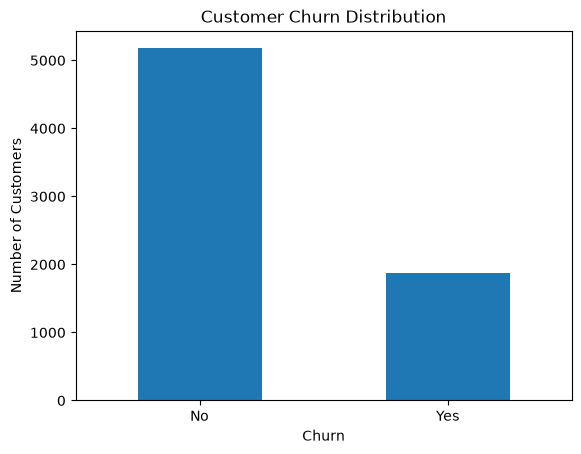

In [12]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [ ]:
CHECK CUSTOMER DEMOGRAPHICS

In [13]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [ ]:
VISUALIZE IT

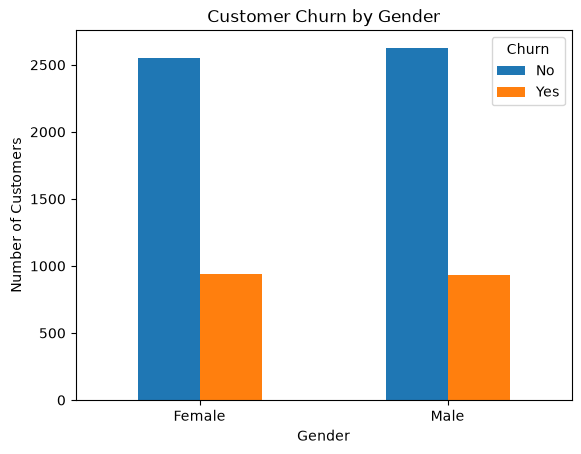

In [15]:
pd.crosstab(df["gender"], df["Churn"]).plot(kind="bar")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [ ]:
CONTRACT TYPE VS CHURN

In [16]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
CALCULATE CHURN RATE FOR CONTACT

In [17]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
VISUALIZE CHURN RATE BY CONTACTS

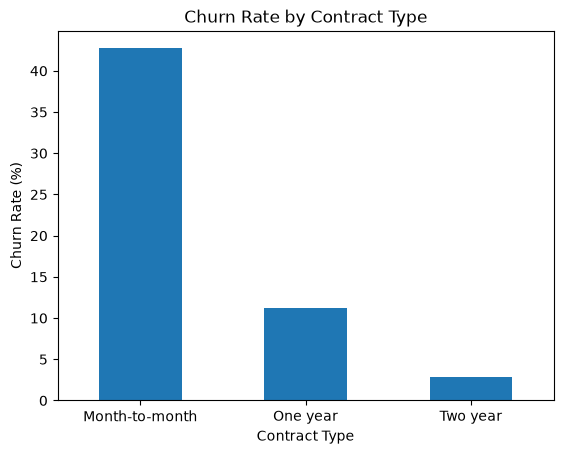

In [18]:
contract_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
CHECK TENURE VS CHURN

In [19]:
pd.crosstab(df["tenure"], df["Churn"])

Churn,No,Yes
tenure,,
0,11,0
1,233,380
2,115,123
3,106,94
4,93,83
...,...,...
68,91,9
69,87,8
70,108,11


In [ ]:
CALCULATE CHURN RATE BY TENEURE

In [20]:
tenure_churn_rate = pd.crosstab(
    df["tenure"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn_rate.head(10)

Churn,No,Yes
tenure,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
5,51.879699,48.120301
6,63.636364,36.363636
7,61.068702,38.931298
8,65.853659,34.146341


In [21]:
tenure_churn_rate.tail(10)

Churn,No,Yes
tenure,,
63,94.444444,5.555556
64,95.000000,5.000000
65,88.157895,11.842105
66,85.393258,14.606742
67,89.795918,10.204082
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697
71,96.470588,3.529412


In [ ]:
PLOT CHURN RATE VS TENURE

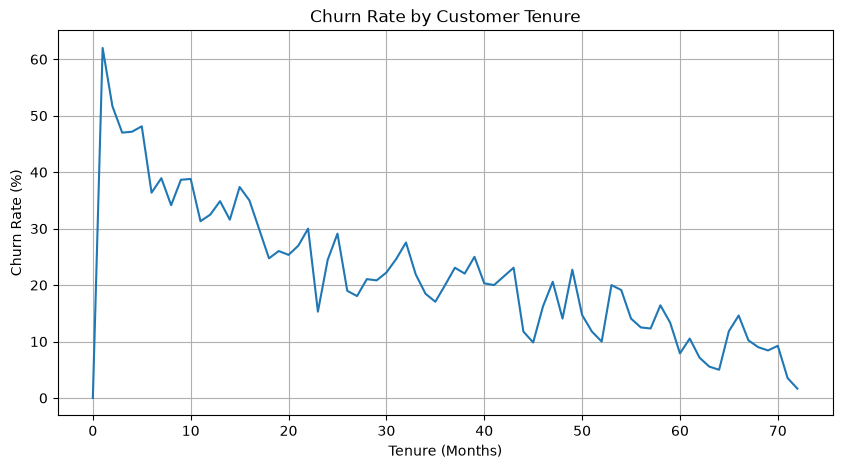

In [22]:
tenure_churn_rate["Yes"].plot(
    kind="line",
    figsize=(10, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.grid(True)

plt.show()

In [ ]:
MONTHLY CHARGES VS CHURN

In [23]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [ ]:
VISUALIZE MONTHLY CHARGES VS CHURN

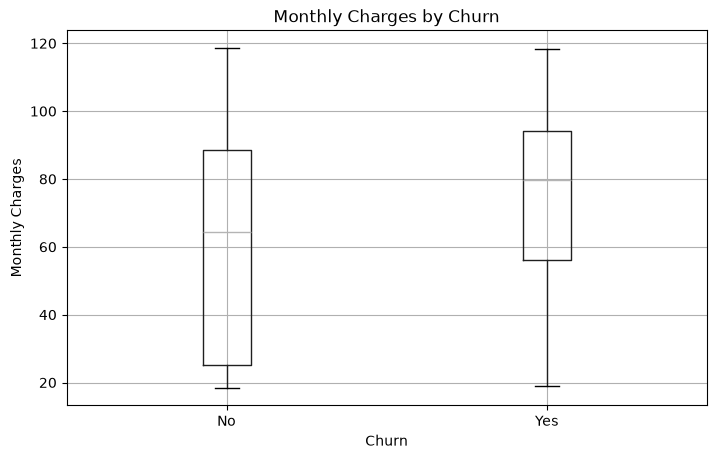

In [24]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(8, 5)
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
TOTAL CHARGES VS CHURN

In [25]:
df.groupby("Churn")["TotalCharges"].describe()

,count,unique,top,freq
Churn,,,,
No,5174,4966,,11
Yes,1869,1732,20.2,6


In [26]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [28]:
df["TotalCharges"] = pd.to_numeric(                                                        #CONVERT TOTAL CHARGES TO NUMERIC.
    df["TotalCharges"],
    errors="coerce"
)                                            

In [29]:
df["TotalCharges"].dtype      #DATATYPE CHECK

dtype('float64')

In [30]:
df["TotalCharges"].isna().sum()   #HOW MANY MISSING VALUES ARE CREATED.

np.int64(11)

In [31]:
df[df["TotalCharges"].isna()][                                             #CHECK THOSE 11 ROWS.
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [32]:
df["TotalCharges"] = df["TotalCharges"].fillna(0) #HANDLE MISSING VALUES

In [33]:
df["TotalCharges"].isna().sum()                 #NOW CHECKING

np.int64(0)

In [34]:
df["TotalCharges"].dtype

dtype('float64')

In [35]:
df.groupby("Churn")["TotalCharges"].describe()   #ANALYZE TOTAL CHARGES VS CHURN

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


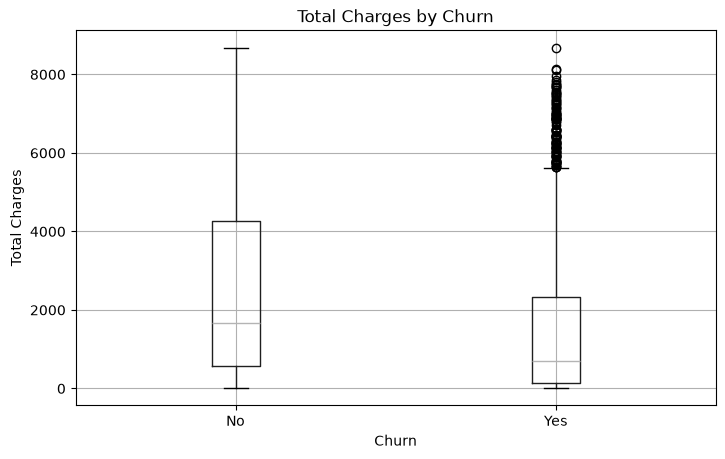

In [37]:
df.boxplot(                                                          #VISUALIZE TOTAL VS CHURN
    column="TotalCharges",
    by="Churn",
    figsize=(8, 5)
)

plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [38]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [39]:
internet_churn_rate = pd.crosstab(    #CHURN RATE BY INTERNET SERVICES
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [40]:
pd.crosstab(                                 #PAYMENT METHOD VS CHURN
    df["PaymentMethod"],
    df["Churn"]
)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [41]:
payment_churn_rate = pd.crosstab(           #CALCULATE CHURN RATE BY PAYMENT METHOD
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


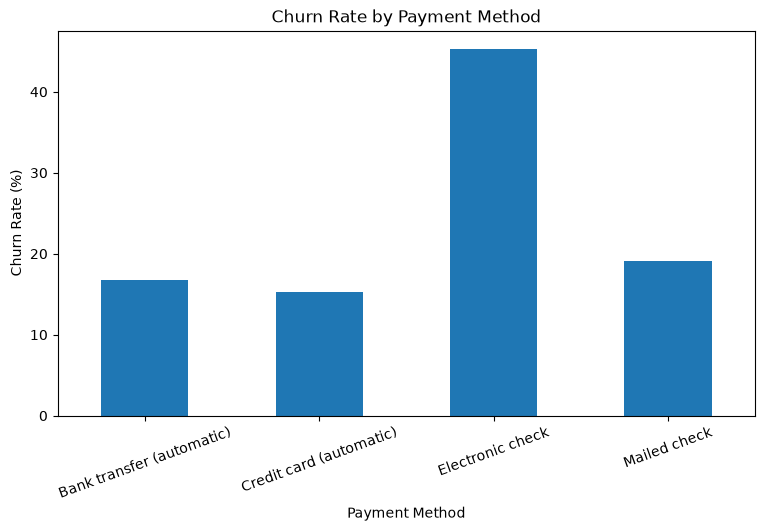

In [42]:
payment_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()                                                       #VISUALIZE PAYMENT  METHOD  CHURN 

In [43]:
pd.crosstab(                                     #ONLINE SECURITY VSA CHURN
    df["OnlineSecurity"],
    df["Churn"]
)

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [44]:
security_churn_rate = pd.crosstab(                         #CHURN RATE BY ONLINE SECURITY
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn_rate

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


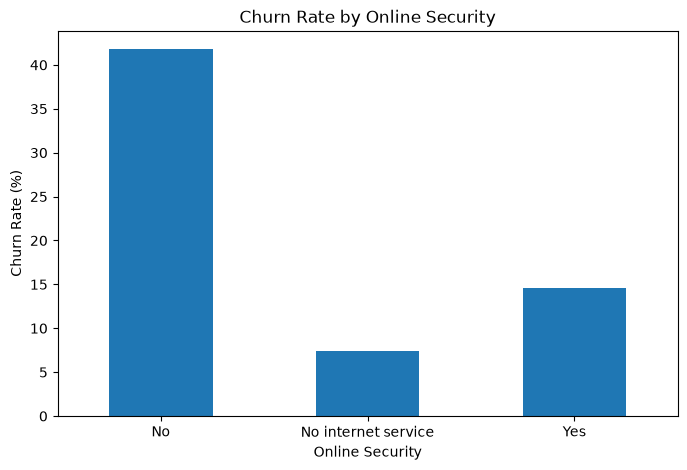

In [45]:
security_churn_rate["Yes"].plot(          #VISUALIZING IT
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [46]:
pd.crosstab(                                    #TECH SUPPORT VS CHURN
    df["TechSupport"],
    df["Churn"]
)

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [ ]:
CHURN RATE BY TECH SUPPORT

In [47]:
techsupport_churn_rate = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn_rate

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


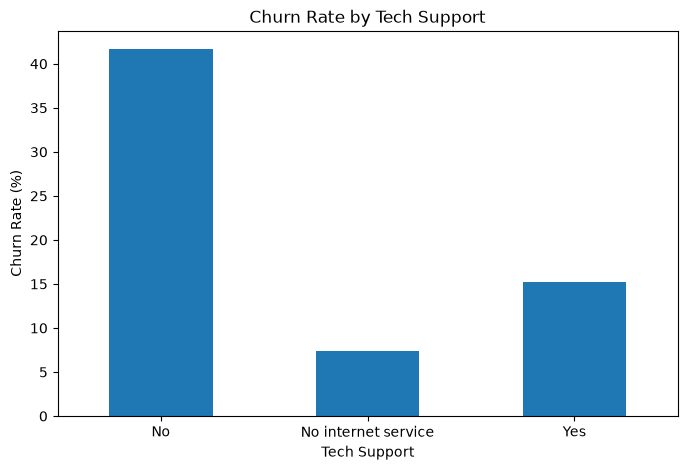

In [48]:
techsupport_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
SENIOR CITIZENS VS CHURN

In [49]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [ ]:
SENIOR CITIZEN CHURN RATE

In [50]:
senior_churn_rate = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn_rate

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


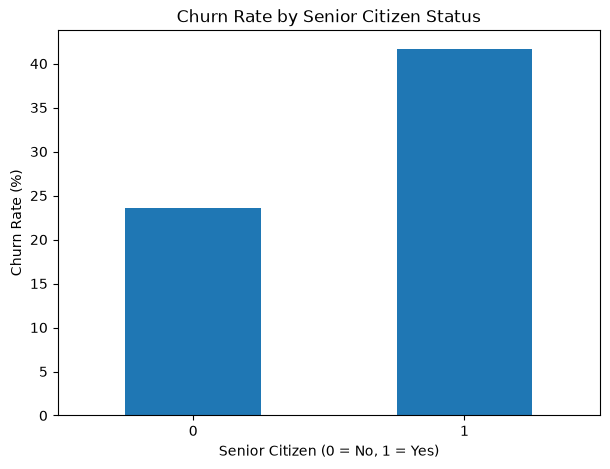

In [51]:
senior_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
PAPERLESS BILLING VS CHURN

In [52]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"]
)

Churn,No,Yes
PaperlessBilling,,
No,2403,469
Yes,2771,1400


In [53]:
paperless_churn_rate = pd.crosstab(        #CHURN RATE BY PAPERLESS BILLING
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn_rate

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


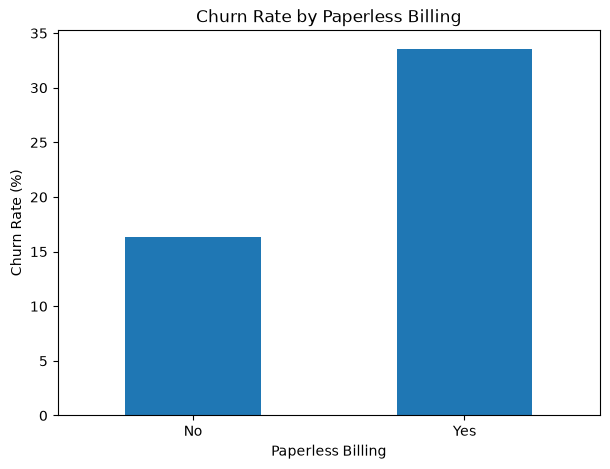

In [54]:
paperless_churn_rate["Yes"].plot(     #VISUALIZE
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [55]:
pd.crosstab(      #PARTNER  VS CHURN
    df["Partner"],
    df["Churn"]
)

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [56]:
partner_churn_rate = pd.crosstab(    #CHURN RATE BY PARTNER
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn_rate

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


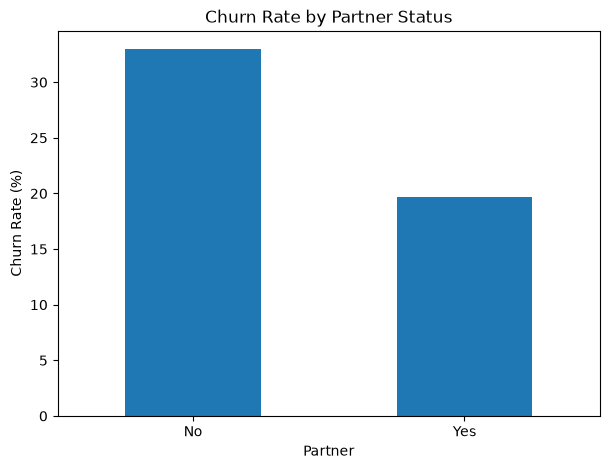

In [57]:
partner_churn_rate["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [58]:
pd.crosstab(   #DEPENDENTS VS CHURN
    df["Dependents"],
    df["Churn"]
)

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [59]:
dependents_churn_rate = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn_rate                                             #CHURN RATE BY DEPENDENTS

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


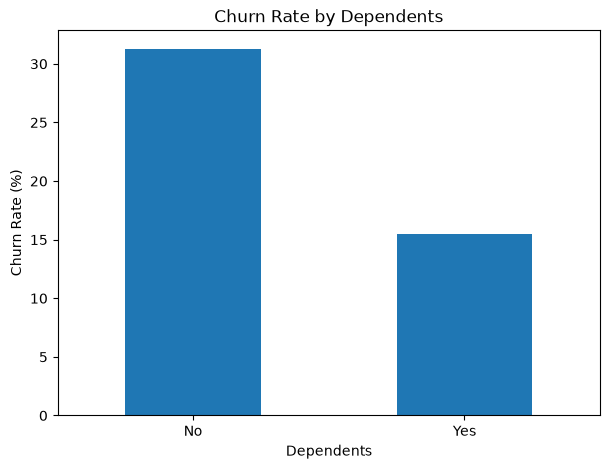

In [60]:
dependents_churn_rate["Yes"].plot(                            #VISUALIZING
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [61]:
df.isnull().sum()             #FINAL EDA CHECK

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [62]:
df.duplicated().sum()   #CHECKING DUPLICATE ROWS

np.int64(0)

In [63]:
df = df.drop("customerID", axis=1)   #REMOVING CUSTOMER ID

In [64]:
df.head

<bound method NDFrame.head of       gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL         

In [65]:
df["Churn"] = df["Churn"].map({                   #convert churn into 0 $ 1.
    "No": 0,
    "Yes": 1
})

In [66]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [67]:
df = pd.get_dummies(                                          #ENCODED CATEGORICAL COLUMNS
    df,
    columns=df.select_dtypes(include=["string", "object"]).columns,
    drop_first=True,
    dtype=int
)

In [70]:
df.head

<bound method NDFrame.head of       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0                 0       1           29.85         29.85      0            0   
1                 0      34           56.95       1889.50      0            1   
2                 0       2           53.85        108.15      1            1   
3                 0      45           42.30       1840.75      0            1   
4                 0       2           70.70        151.65      1            0   
...             ...     ...             ...           ...    ...          ...   
7038              0      24           84.80       1990.50      0            1   
7039              0      72          103.20       7362.90      0            0   
7040              0      11           29.60        346.45      0            0   
7041              1       4           74.40        306.60      1            1   
7042              0      66          105.65       6844.50      0            1  

In [71]:
df.shape

(7043, 31)

In [72]:
X = df.drop("Churn", axis=1)    #X = all features we'll use to predict churn
y = df["Churn"]                 #y = the thing we want to predict → Churn 


In [73]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [75]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 4.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 4.7 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 4.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.3 MB 4.3 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 4.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 4.2 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.9 MB/s  0:00:02
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.3/37.4 MB 7.0 MB/s eta 0:00:06
   -- ---------------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from sklearn.model_selection import train_test_split                                  #train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [79]:
from sklearn.preprocessing import StandardScaler                              #Standard scaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5634, 30)
X_test_scaled shape: (1409, 30)


In [81]:
from sklearn.linear_model import LogisticRegression           #train logistic reg.

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [82]:
y_pred = log_model.predict(X_test_scaled) #testing

In [83]:
print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [84]:
from sklearn.metrics import (            #model evaluation
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1 Score : 0.6091954022988506


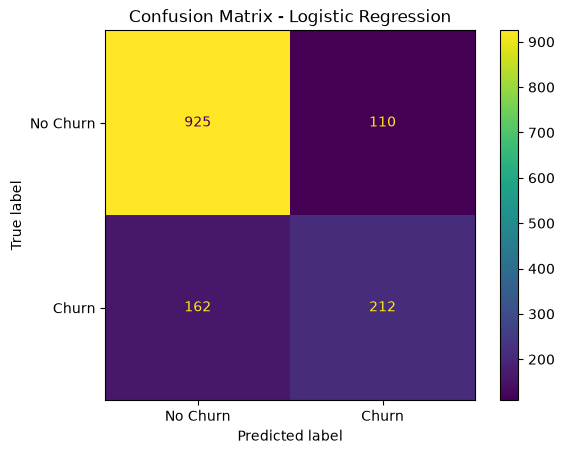

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [86]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.841778397788628


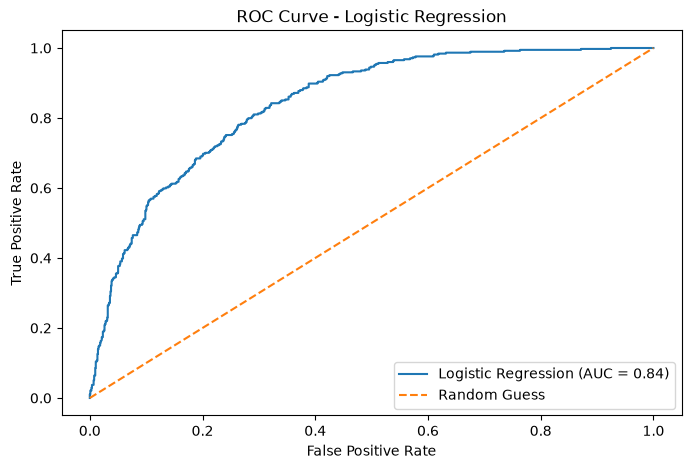

In [87]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [88]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [89]:
y_pred_dt = dt_model.predict(X_test)

In [90]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
Accuracy : 0.7260468417317246
Precision: 0.4837837837837838
Recall   : 0.4786096256684492
F1 Score : 0.48118279569892475


In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [92]:
y_pred_rf = rf_model.predict(X_test)

In [93]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
Accuracy : 0.7927608232789212
Precision: 0.6366666666666667
Recall   : 0.5106951871657754
F1 Score : 0.5667655786350149


In [94]:
results = pd.DataFrame({           #model comparision table
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195
1,Decision Tree,0.726047,0.483784,0.478610,0.481183
2,Random Forest,0.792761,0.636667,0.510695,0.566766


In [95]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.8264408793820558


In [96]:
roc_auc_log = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test_scaled)[:, 1]
)

print("Logistic Regression ROC-AUC:", roc_auc_log)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 0.841778397788628
Random Forest ROC-AUC: 0.8264408793820558


In [97]:
results["ROC-AUC"] = [         ##adding roc-auc in result table.
    roc_auc_log,
    np.nan,
    roc_auc_rf
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,Decision Tree,0.726047,0.483784,0.478610,0.481183,NaN
2,Random Forest,0.792761,0.636667,0.510695,0.566766,0.826441


In [99]:
balanced_log_model = LogisticRegression(             #Train a class-balanced Logistic Regression
    class_weight="balanced",
    random_state=42
)

balanced_log_model.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [100]:
y_pred_balanced = balanced_log_model.predict(X_test_scaled)

In [101]:
accuracy_bal = accuracy_score(y_test, y_pred_balanced)
precision_bal = precision_score(y_test, y_pred_balanced)
recall_bal = recall_score(y_test, y_pred_balanced)
f1_bal = f1_score(y_test, y_pred_balanced)

print("Balanced Logistic Regression")
print("Accuracy :", accuracy_bal)
print("Precision:", precision_bal)
print("Recall   :", recall_bal)
print("F1 Score :", f1_bal)

Balanced Logistic Regression
Accuracy : 0.7402413058907026
Precision: 0.506896551724138
Recall   : 0.786096256684492
F1 Score : 0.6163522012578616


In [102]:
#60#ROC-AUC of Balanced Logistic Regression
y_prob_balanced = balanced_log_model.predict_proba(
    X_test_scaled
)[:, 1]

roc_auc_balanced = roc_auc_score(
    y_test,
    y_prob_balanced
)

print("Balanced Logistic Regression ROC-AUC:", roc_auc_balanced)


Balanced Logistic Regression ROC-AUC: 0.8414012245214291


In [103]:
#61 — Balanced Logistic Regression ROC-AUC
results["ROC-AUC"] = [         ##adding roc-auc in result table.
    roc_auc_log,
    np.nan,
    roc_auc_rf
]

results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,Decision Tree,0.726047,0.483784,0.478610,0.481183,NaN
2,Random Forest,0.792761,0.636667,0.510695,0.566766,0.826441


In [104]:
#62 CHECK CHURN PROBABILITY DISTRIBUTION
y_prob_balanced = balanced_log_model.predict_proba(X_test_scaled)[:, 1]

print(y_prob_balanced[:20])

[0.11837823 0.85164028 0.14131508 0.66493518 0.06142382 0.80535184
 0.69950956 0.2938187  0.00883709 0.65216157 0.51770126 0.15207917
 0.30701981 0.85318724 0.30208286 0.14812107 0.07869212 0.81830903
 0.37874035 0.20660797]


In [105]:
#63 CHECK DIFFERENT CLASSIFICATION THRESHHOLD
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_balanced >= threshold).astype(int)

    precision_t = precision_score(y_test, y_pred_threshold)
    recall_t = recall_score(y_test, y_pred_threshold)
    f1_t = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision_t:.3f}")
    print(f"Recall:    {recall_t:.3f}")
    print(f"F1 Score:  {f1_t:.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.429
Recall:    0.925
F1 Score:  0.586
------------------------------
Threshold: 0.4
Precision: 0.465
Recall:    0.866
F1 Score:  0.605
------------------------------
Threshold: 0.5
Precision: 0.507
Recall:    0.786
F1 Score:  0.616
------------------------------
Threshold: 0.6
Precision: 0.541
Recall:    0.706
F1 Score:  0.613
------------------------------
Threshold: 0.7
Precision: 0.598
Recall:    0.602
F1 Score:  0.600
------------------------------


In [106]:
#64 Final Confusion Matrix for Our Chosen Model
final_threshold = 0.5

y_pred_final = (
    y_prob_balanced >= final_threshold
).astype(int)

[[749 286]
 [ 80 294]]


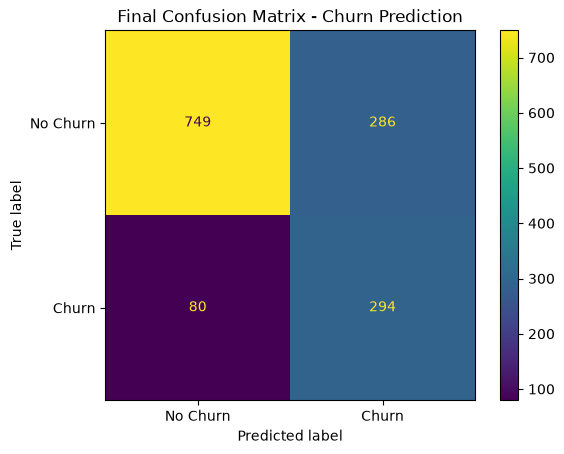

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Final Confusion Matrix - Churn Prediction")
plt.show()

In [108]:
#65 FINAL CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [109]:
#66 Find the Most Important Churn Features
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": balanced_log_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.159048,1.159048
2,MonthlyCharges,-1.039440,1.039440
10,InternetService_Fiber optic,0.808897,0.808897
25,Contract_Two year,-0.617746,0.617746
3,TotalCharges,0.494748,0.494748
24,Contract_One year,-0.296706,0.296706
23,StreamingMovies_Yes,0.285948,0.285948
21,StreamingTV_Yes,0.273209,0.273209
9,MultipleLines_Yes,0.201165,0.201165
28,PaymentMethod_Electronic check,0.188783,0.188783


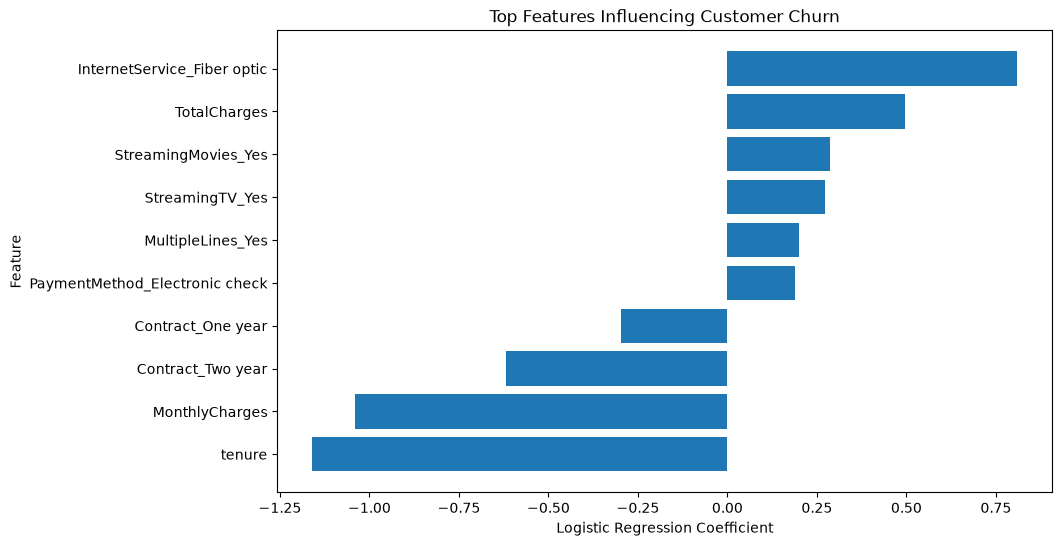

In [110]:
#67 VISUALIZE FEATURE IMPORTANCE
top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [111]:
import joblib

joblib.dump(
    balanced_log_model,
    "churn_model.pkl"
)

['churn_model.pkl']

In [112]:
joblib.dump(
    scaler,
    "churn_scaler.pkl"
)

['churn_scaler.pkl']

In [113]:
import os

print(os.path.exists("churn_model.pkl"))
print(os.path.exists("churn_scaler.pkl"))

True
True


In [114]:
#69 SAVING FEATURE NAME
joblib.dump(
    X.columns.tolist(),
    "churn_features.pkl"
)

['churn_features.pkl']

In [115]:
features = joblib.load("churn_features.pkl")  #VERIFYING

print("Number of features:", len(features))
print(features)

Number of features: 30
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [116]:
#70 TEST LOADING EVERYTHING
loaded_model = joblib.load("churn_model.pkl")
loaded_scaler = joblib.load("churn_scaler.pkl")
loaded_features = joblib.load("churn_features.pkl")

print("Model loaded:", type(loaded_model))
print("Scaler loaded:", type(loaded_scaler))
print("Features:", len(loaded_features))

Model loaded: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>
Features: 30


In [117]:
#71 MAKE A REAL PREDICION
sample_customer = X_test.iloc[[0]]

sample_customer_scaled = loaded_scaler.transform(sample_customer)

churn_probability = loaded_model.predict_proba(
    sample_customer_scaled
)[0][1]

churn_prediction = loaded_model.predict(
    sample_customer_scaled
)[0]

print("Churn Probability:", round(churn_probability * 100, 2), "%")
print("Prediction:", "Churn" if churn_prediction == 1 else "No Churn")

Churn Probability: 11.84 %
Prediction: No Churn


In [118]:
#72 CHECKING ACTUAL OUTCOME
actual_value = y_test.iloc[0]

print(
    "Actual:",
    "Churn" if actual_value == 1 else "No Churn"
)

Actual: No Churn


In [119]:
#73Create a Reusable Prediction Function
def predict_churn(customer_data):
    customer_data = customer_data[loaded_features]

    customer_scaled = loaded_scaler.transform(customer_data)

    probability = loaded_model.predict_proba(customer_scaled)[0][1]

    prediction = loaded_model.predict(customer_scaled)[0]

    return {
        "Churn Probability": round(probability * 100, 2),
        "Prediction": "Churn" if prediction == 1 else "No Churn"
    }

In [120]:
result = predict_churn(sample_customer) #TESTING IT ON SAMPLE CUSTOMER

print(result)

{'Churn Probability': np.float64(11.84), 'Prediction': 'No Churn'}


In [121]:
#74 create a proper new-customer input example
def predict_new_customer(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):
    new_customer = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges
    }])

    # Convert categorical columns exactly like training data
    new_customer = pd.get_dummies(
        new_customer,
        columns=new_customer.select_dtypes(
            include=["string", "object"]
        ).columns,
        drop_first=True,
        dtype=int
    )

    # Match the exact feature structure used during training
    new_customer = new_customer.reindex(
        columns=loaded_features,
        fill_value=0
    )

    # Scale using the saved scaler
    customer_scaled = loaded_scaler.transform(new_customer)

    # Prediction
    probability = loaded_model.predict_proba(
        customer_scaled
    )[0][1]

    prediction = loaded_model.predict(
        customer_scaled
    )[0]

    print("Churn Probability:", round(probability * 100, 2), "%")
    print(
        "Prediction:",
        "Churn" if prediction == 1 else "No Churn"
    )

In [122]:
#TESTING A HIGH RISK CUSTOMER
predict_new_customer(
    gender="Female",
    senior_citizen=0,
    partner="No",
    dependents="No",
    tenure=3,
    phone_service="Yes",
    multiple_lines="No",
    internet_service="Fiber optic",
    online_security="No",
    online_backup="No",
    device_protection="No",
    tech_support="No",
    streaming_tv="Yes",
    streaming_movies="Yes",
    contract="Month-to-month",
    paperless_billing="Yes",
    payment_method="Electronic check",
    monthly_charges=90.0,
    total_charges=270.0
)

Churn Probability: 20.24 %
Prediction: No Churn


In [123]:
#76 TEST A LOW RISK CUSTOMER
predict_new_customer(
    gender="Male",
    senior_citizen=0,
    partner="Yes",
    dependents="Yes",
    tenure=60,
    phone_service="Yes",
    multiple_lines="No",
    internet_service="DSL",
    online_security="Yes",
    online_backup="Yes",
    device_protection="Yes",
    tech_support="Yes",
    streaming_tv="No",
    streaming_movies="No",
    contract="Two year",
    paperless_billing="No",
    payment_method="Credit card (automatic)",
    monthly_charges=60.0,
    total_charges=3600.0
)

Churn Probability: 9.09 %
Prediction: No Churn


In [124]:
#77 CREATING A RISK CATEGORY
def churn_risk_category(probability):
    if probability < 30:
        return "Low Risk"
    elif probability < 60:
        return "Medium Risk"
    else:
        return "High Risk"

In [125]:
probability = 20.24 #TESTING IT 

print("Risk Category:", churn_risk_category(probability))

Risk Category: Low Risk


In [126]:
#78 — Create a Final Model Summary
print("FINAL MODEL: Balanced Logistic Regression")
print("-" * 45)

print(f"Accuracy : {accuracy_bal:.2%}")
print(f"Precision: {precision_bal:.2%}")
print(f"Recall   : {recall_bal:.2%}")
print(f"F1 Score : {f1_bal:.2%}")
print(f"ROC-AUC  : {roc_auc_balanced:.2%}")
print(f"Threshold: {final_threshold}")

FINAL MODEL: Balanced Logistic Regression
---------------------------------------------
Accuracy : 74.02%
Precision: 50.69%
Recall   : 78.61%
F1 Score : 61.64%
ROC-AUC  : 84.14%
Threshold: 0.5


In [127]:
#79 SAVING FINAL MODEL 
model_info = {
    "model": "Balanced Logistic Regression",
    "accuracy": accuracy_bal,
    "precision": precision_bal,
    "recall": recall_bal,
    "f1_score": f1_bal,
    "roc_auc": roc_auc_balanced,
    "threshold": final_threshold,
    "features": loaded_features
}

joblib.dump(model_info, "model_info.pkl")

print("Model information saved successfully.")

Model information saved successfully.


In [129]:
#80 SAVING MODEL INFORMATION
import os

files_to_check = [
    "churn_model.pkl",
    "churn_scaler.pkl",
    "churn_features.pkl",
    "model_info.pkl"
]

for file in files_to_check:
    print(file, "->", os.path.exists(file))

churn_model.pkl -> True
churn_scaler.pkl -> True
churn_features.pkl -> True
model_info.pkl -> True


In [131]:
%pip install streamlit

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.5 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/10.5 MB 4.4 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/10.5 MB 3.7 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/10.5 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/10.5 MB 3.7 MB/s eta 0:00:02
   ------------------ --------------------- 5.0/10.5 MB 3.8 MB/s eta 0:00:02
   ----------------------------- ---------- 7.9/10.5 MB 3.6 MB/s eta 0:00:01
   ------------------------------- -------- 8.4/10.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.5 MB 3.5 MB/s eta 0:00:01
   -------------------------------------- - 10.2/10.5 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 3.5 MB/s  0:00:03
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   ----------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
